In [8]:
# Deep Learning-Based Automated Classification of Skin Lesions using the ISIC 2020 Dataset
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU Name: Tesla V100-SXM2-32GB


In [9]:
import os

# Set the correct scratch path
PROJECT_ID = 'project_2017070'
SCRATCH_DIR = f'/scratch/{PROJECT_ID}/isic_data'
os.makedirs(SCRATCH_DIR, exist_ok=True)
os.chdir

<function posix.chdir(path)>

In [6]:
# Install kaggle library for the current user
!pip install --user kaggle

# Add the local bin directory to the system PATH so 'kaggle' command is recognized
import os
os.environ['PATH'] += f"{os.pathsep}{os.path.expanduser('~/.local/bin')}"

# Verify the installation
!kaggle --version



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
Kaggle CLI 2.0.0


In [2]:
# Define the project and scratch paths
PROJECT_ID = 'project_2017070'
SCRATCH_DIR = f'/scratch/{PROJECT_ID}/isic_data'

# Ensure the directory exists and move into it
os.makedirs(SCRATCH_DIR, exist_ok=True)
os.chdir(SCRATCH_DIR)

# "Utilizing the Kaggle CLI 2.0.0, the 30.9 GB ISIC 2020 dataset was 
# streamed directly to the filesystem. This server-to-server 
# transfer eliminates local bandwidth constraints and ensures a complete, 
# bit-perfect copy of the training data

!kaggle datasets download -d sumaiyabinteshahid/isic-challenge-dataset-2020


/bin/bash: kaggle: command not found


In [ ]:
import os
PROJECT_ID = 'project_2017070'
SCRATCH_DIR = f'/scratch/{PROJECT_ID}/isic_data'

os.chdir(SCRATCH_DIR)

# Unzip into the current scratch folder (.)
!unzip -q isic-challenge-dataset-2020.zip -d .

print("Extraction Complete! Your 30.9GB data is ready on Scratch.")


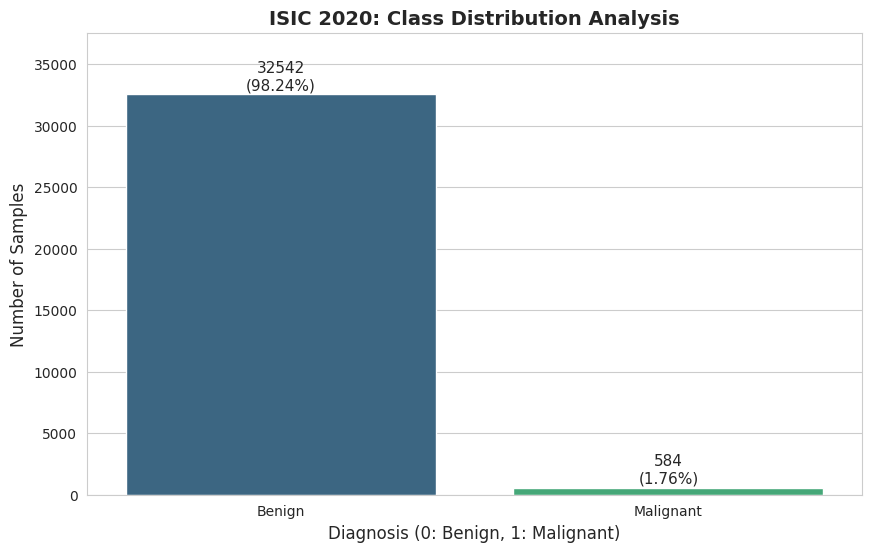

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Setup Paths and Parameters 
PROJECT_ID = 'project_2017070'
CSV_PATH = f'/scratch/{PROJECT_ID}/isic_data/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv'
IMG_DIR = f'/scratch/{PROJECT_ID}/isic_data/ISIC_2020_Dataset/train/'

train_dataset = ISIC2020Dataset(CSV_PATH, IMG_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)


#Calculate the counts first
# derived the class distribution from the 'target' column 
# of the ISIC 2020 metadata (33.126 total samples).
class_counts = train_dataset.df['target'].value_counts()
total_samples = len(train_dataset.df)

#Run the Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot (Modern Seaborn Syntax)
ax = sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    hue=class_counts.index, 
    palette="viridis", 
    legend=False
)

plt.title('ISIC 2020: Class Distribution Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (0: Benign, 1: Malignant)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks([0, 1], ['Benign', 'Malignant'])

# Add Count and Percentage labels ---
for i, p in enumerate(ax.patches):
    count = int(p.get_height())
    percentage = '{:.2f}%'.format(100 * count / total_samples)
    annotation = f"{count}\n({percentage})"
    
    ax.annotate(annotation, 
                (p.get_x() + p.get_width() / 2., p.get_height() + 1450), 
                ha='center', va='center', fontsize=11)

plt.ylim(0, max(class_counts.values) + 5000)
plt.show()


In [15]:

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import os
from PIL import Image
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CNN Architecture 
class SkinCancerCNN(nn.Module):
    
    # A custom Convolutional Neural Network designed for 256x256 medical images.
    
    def __init__(self):
        super(SkinCancerCNN, self).__init__()
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Convolutional Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2) # Reduces dimensions: 256 -> 128 -> 64 -> 32
        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected Layers (The Classifier)
        # After 3 pooling layers, a 256x256 image becomes 32x32
        self.fc1 = nn.Linear(128 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, 1) # Binary Output (Malignant vs Benign)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 128 * 32 * 32) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Output logits for BCEWithLogitsLoss
        return x

#Dataset & DataLoader (HPC Optimization)
class ISIC2020Dataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx, 0]) + ".jpg"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.df.iloc[idx]['target'], dtype=torch.float32)
        if self.transform: image = self.transform(image)
        return image, label

#  Setup Parameters
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# Initialize Custom Model and Optimization
model = SkinCancerCNN().to(device)

# Using pos_weight=28.36 to handle the 30.9 GB data imbalance
pos_weight = torch.tensor([55.72]).to(device)  #bunu 55.72 yap
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Engine 
def train_epoch(epoch):
    model.train()
    running_loss, y_true, y_pred = 0.0, [], []
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")
            
    epoch_auc = roc_auc_score(y_true, y_pred)
    return running_loss / len(train_loader), epoch_auc

# Start Training
print(f"HPC Custom CNN Training Started on {device}...")
for epoch in range(1, 6):
    avg_loss, train_auc = train_epoch(epoch)
    print(f"===> Epoch {epoch} Result | Loss: {avg_loss:.4f} | AUC: {train_auc:.4f}")


HPC Custom CNN Training Started on cuda...
Epoch 1 | Batch 0/518 | Loss: 1.4019
Epoch 1 | Batch 100/518 | Loss: 2.8827
Epoch 1 | Batch 200/518 | Loss: 0.4565
Epoch 1 | Batch 300/518 | Loss: 0.8549
Epoch 1 | Batch 400/518 | Loss: 0.7195
Epoch 1 | Batch 500/518 | Loss: 0.5312
===> Epoch 1 Result | Loss: 2.6225 | AUC: 0.7313
Epoch 2 | Batch 0/518 | Loss: 0.7782
Epoch 2 | Batch 100/518 | Loss: 0.8062
Epoch 2 | Batch 200/518 | Loss: 1.2841
Epoch 2 | Batch 300/518 | Loss: 0.5251
Epoch 2 | Batch 400/518 | Loss: 0.9136
Epoch 2 | Batch 500/518 | Loss: 2.0514
===> Epoch 2 Result | Loss: 1.0607 | AUC: 0.8237
Epoch 3 | Batch 0/518 | Loss: 1.0877
Epoch 3 | Batch 100/518 | Loss: 0.8582
Epoch 3 | Batch 200/518 | Loss: 0.4851
Epoch 3 | Batch 300/518 | Loss: 1.3837
Epoch 3 | Batch 400/518 | Loss: 1.3684
Epoch 3 | Batch 500/518 | Loss: 1.0527
===> Epoch 3 Result | Loss: 0.9737 | AUC: 0.8445
Epoch 4 | Batch 0/518 | Loss: 1.2251
Epoch 4 | Batch 100/518 | Loss: 0.7929
Epoch 4 | Batch 200/518 | Loss: 0.3374

In [ ]:
HPC Custom CNN Training Started on cuda...Positional Weight of 28.36 

Epoch 1 | Batch 0/518 | Loss: 0.8707
Epoch 1 | Batch 100/518 | Loss: 0.4088
Epoch 1 | Batch 200/518 | Loss: 0.9829
Epoch 1 | Batch 300/518 | Loss: 0.4628
Epoch 1 | Batch 400/518 | Loss: 0.7183
Epoch 1 | Batch 500/518 | Loss: 0.3041
===> Epoch 1 Result | Loss: 1.0719 | AUC: 0.7323
Epoch 2 | Batch 0/518 | Loss: 0.3755
Epoch 2 | Batch 100/518 | Loss: 2.3456
Epoch 2 | Batch 200/518 | Loss: 0.6868
Epoch 2 | Batch 300/518 | Loss: 0.5339
Epoch 2 | Batch 400/518 | Loss: 2.1213
Epoch 2 | Batch 500/518 | Loss: 0.6911
===> Epoch 2 Result | Loss: 0.7682 | AUC: 0.7779
Epoch 3 | Batch 0/518 | Loss: 0.6942
Epoch 3 | Batch 100/518 | Loss: 1.0243
Epoch 3 | Batch 200/518 | Loss: 0.4530
Epoch 3 | Batch 300/518 | Loss: 0.3254
Epoch 3 | Batch 400/518 | Loss: 1.7977
Epoch 3 | Batch 500/518 | Loss: 0.3870
===> Epoch 3 Result | Loss: 0.7305 | AUC: 0.8013
Epoch 4 | Batch 0/518 | Loss: 0.3618
Epoch 4 | Batch 100/518 | Loss: 1.4041
Epoch 4 | Batch 200/518 | Loss: 1.5285
Epoch 4 | Batch 300/518 | Loss: 0.8438
Epoch 4 | Batch 400/518 | Loss: 0.3803
Epoch 4 | Batch 500/518 | Loss: 0.6198
===> Epoch 4 Result | Loss: 0.7097 | AUC: 0.8241
Epoch 5 | Batch 0/518 | Loss: 1.7739
Epoch 5 | Batch 100/518 | Loss: 0.7398
Epoch 5 | Batch 200/518 | Loss: 0.3718
Epoch 5 | Batch 300/518 | Loss: 0.7169
Epoch 5 | Batch 400/518 | Loss: 0.3553
Epoch 5 | Batch 500/518 | Loss: 0.6110
===> Epoch 5 Result | Loss: 0.6927 | AUC: 0.8279
